# Goal:
Assess the viability of supervised learning approaches

In [2]:
# Core
import numpy as np
import pandas as pd

# Visualization (optional but useful for diagnostics)
import matplotlib.pyplot as plt
import seaborn as sns

# Data prep and evaluation
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Supervised regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

# XGBoost
from xgboost import XGBRegressor

In [3]:
# conduct k-NN to find 5 nearest neighbors

train_df= pd.read_csv("5411_train_temporal_with_costs.csv")
val_df= pd.read_csv("5411_validate_temporal_with_costs.csv")
test_df= pd.read_csv("5411_test_temporal_with_costs.csv")

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)  

train_df.info()

all_df.info()



<class 'pandas.DataFrame'>
RangeIndex: 167323 entries, 0 to 167322
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   transaction_id   167323 non-null  int64  
 1   date             167323 non-null  str    
 2   amount           167323 non-null  float64
 3   use_chip         167323 non-null  str    
 4   merchant_id      167323 non-null  int64  
 5   mcc              167323 non-null  float64
 6   errors           1888 non-null    str    
 7   card_brand       167323 non-null  str    
 8   card_type        167323 non-null  str    
 9   mcc_description  167323 non-null  str    
 10  cost_type_ID     153992 non-null  float64
 11  proc_cost        153992 non-null  float64
dtypes: float64(4), int64(2), str(6)
memory usage: 27.5 MB
<class 'pandas.DataFrame'>
RangeIndex: 473012 entries, 0 to 473011
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------

In [4]:
# remove error cost_type_ID

all_df = all_df[all_df['cost_type_ID'] != 'NaN']
train_df = train_df[train_df['cost_type_ID'] != 'NaN']
val_df = val_df[val_df['cost_type_ID'] != 'NaN']
test_df = test_df[test_df['cost_type_ID'] != 'NaN']

train_df = train_df.dropna(subset=['cost_type_ID'])
val_df = val_df.dropna(subset=['cost_type_ID'])
test_df = test_df.dropna(subset=['cost_type_ID'])
all_df = all_df.dropna(subset=['cost_type_ID'])

# keep only rows with no recorded errors in the training set
train_df = train_df[train_df['errors'].isna()].copy()
val_df = val_df[val_df['errors'].isna()].copy()
test_df = test_df[test_df['errors'].isna()].copy()
all_df = all_df[all_df['errors'].isna()].copy()

train_df.info()

<class 'pandas.DataFrame'>
Index: 152241 entries, 0 to 167322
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   transaction_id   152241 non-null  int64  
 1   date             152241 non-null  str    
 2   amount           152241 non-null  float64
 3   use_chip         152241 non-null  str    
 4   merchant_id      152241 non-null  int64  
 5   mcc              152241 non-null  float64
 6   errors           0 non-null       str    
 7   card_brand       152241 non-null  str    
 8   card_type        152241 non-null  str    
 9   mcc_description  152241 non-null  str    
 10  cost_type_ID     152241 non-null  float64
 11  proc_cost        152241 non-null  float64
dtypes: float64(4), int64(2), str(6)
memory usage: 26.3 MB


In [5]:
# make weekly features by merchant

COST_TYPE_IDS = list(range(1, 62))


def build_weekly_merchant_features(df, split_year):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df[df['date'].dt.year == split_year].copy()

    # Force an exact 52-week calendar inside each split year.
    year_start = pd.Timestamp(f'{split_year}-01-01')
    day_offset = (df['date'] - year_start).dt.days
    df['week_of_year'] = np.clip((day_offset // 7) + 1, 1, 52).astype(int)

    df['cost_type_ID'] = pd.to_numeric(df['cost_type_ID'], errors='coerce').astype('Int64')
    df['txn_cost_percent'] = np.where(df['amount'] != 0, df['proc_cost'] / df['amount'], np.nan)

    weekly_summary = (
        df.groupby(['merchant_id', 'week_of_year'], as_index=False)
        .agg(
            total_proc_cost=('proc_cost', 'sum'),
            total_amount=('amount', 'sum'),
            total_transactions=('transaction_id', 'count'),
            cost_percent_stdev=('txn_cost_percent', 'std'),
        )
    )

    weekly_summary['cost_percent'] = np.where(
        weekly_summary['total_amount'] != 0,
        weekly_summary['total_proc_cost'] / weekly_summary['total_amount'],
        np.nan,
    )
    weekly_summary = weekly_summary.drop(columns=['total_proc_cost', 'total_amount'])

    cost_type_counts = (
        df.dropna(subset=['cost_type_ID'])
        .groupby(['merchant_id', 'week_of_year', 'cost_type_ID'])['transaction_id']
        .count()
        .unstack(fill_value=0)
        .reindex(columns=COST_TYPE_IDS, fill_value=0)
    )

    cost_type_pct = cost_type_counts.div(cost_type_counts.sum(axis=1), axis=0).fillna(0)
    cost_type_pct.columns = [f'pct_cost_type_{cost_type_id}' for cost_type_id in cost_type_pct.columns]
    cost_type_pct = cost_type_pct.reset_index()

    weekly_features = weekly_summary.merge(
        cost_type_pct,
        on=['merchant_id', 'week_of_year'],
        how='left',
    )

    merchants = pd.Index(sorted(df['merchant_id'].dropna().unique()), name='merchant_id')
    weeks = pd.Index(range(1, 53), name='week_of_year')
    full_grid = pd.MultiIndex.from_product([merchants, weeks], names=['merchant_id', 'week_of_year']).to_frame(index=False)

    weekly_features = full_grid.merge(
        weekly_features,
        on=['merchant_id', 'week_of_year'],
        how='left',
    )

    pct_cols = [f'pct_cost_type_{cost_type_id}' for cost_type_id in COST_TYPE_IDS]
    weekly_features[pct_cols] = weekly_features[pct_cols].fillna(0.0)
    weekly_features['total_transactions'] = weekly_features['total_transactions'].fillna(0).astype(int)
    weekly_features['split_year'] = split_year

    ordered_cols = [
        'split_year',
        'week_of_year',
        'merchant_id',
        'cost_percent',
        *pct_cols,
        'total_transactions',
        'cost_percent_stdev',
    ]
    weekly_features = weekly_features[ordered_cols].sort_values(['merchant_id', 'week_of_year']).reset_index(drop=True)

    return weekly_features


weekly_train_features = build_weekly_merchant_features(train_df, 2017)
weekly_validate_features = build_weekly_merchant_features(val_df, 2018)
weekly_test_features = build_weekly_merchant_features(test_df, 2019)

print('Train weekly feature shape:', weekly_train_features.shape)
print('Validate weekly feature shape:', weekly_validate_features.shape)
print('Test weekly feature shape:', weekly_test_features.shape)

weekly_train_features.head()

Train weekly feature shape: (144248, 67)
Validate weekly feature shape: (143156, 67)
Test weekly feature shape: (132704, 67)


,split_year,week_of_year,merchant_id,cost_percent,pct_cost_type_1,pct_cost_type_2,pct_cost_type_3,pct_cost_type_4,pct_cost_type_5,pct_cost_type_6,...,pct_cost_type_54,pct_cost_type_55,pct_cost_type_56,pct_cost_type_57,pct_cost_type_58,pct_cost_type_59,pct_cost_type_60,pct_cost_type_61,total_transactions,cost_percent_stdev
0,2017,1,34,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN
1,2017,2,34,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN
2,2017,3,34,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN
3,2017,4,34,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN
4,2017,5,34,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN


In [6]:
# build continuous weekly all_df and isolate new-merchant set for leakage-safe KNN testing

all_weekly_df = pd.concat(
    [weekly_train_features, weekly_validate_features, weekly_test_features],
    ignore_index=True,
).sort_values(['split_year', 'merchant_id', 'week_of_year']).reset_index(drop=True)

# Candidate "new merchants" for Jan 2019 query.
historical_active_2017_2018 = set(
    pd.concat([weekly_train_features, weekly_validate_features], ignore_index=True)
    .loc[lambda d: d['total_transactions'] > 0, 'merchant_id']
    .unique()
)
historical_active_2017 = set(
    weekly_train_features.loc[weekly_train_features['total_transactions'] > 0, 'merchant_id'].unique()
)

jan2019_features = weekly_test_features[
    weekly_test_features['week_of_year'].between(1, 4)
].copy()

jan2019_activity = (
    jan2019_features.assign(active_week=lambda d: d['total_transactions'] > 0)
    .groupby('merchant_id', as_index=False)
    .agg(
        jan_active_weeks=('active_week', 'sum'),
        jan_total_txn=('total_transactions', 'sum'),
    )
)

primary_ids = sorted(
    jan2019_activity.loc[
        (jan2019_activity['jan_active_weeks'] == 4)
        & (~jan2019_activity['merchant_id'].isin(historical_active_2017_2018)),
        'merchant_id',
    ].tolist()
)

if len(primary_ids) > 0:
    new_merchant_ids = primary_ids
    selection_rule = 'primary: no 2017-2018 activity'
else:
    fallback_ids = sorted(
        jan2019_activity.loc[
            (jan2019_activity['jan_active_weeks'] == 4)
            & (~jan2019_activity['merchant_id'].isin(historical_active_2017)),
            'merchant_id',
        ].tolist()
    )

    if len(fallback_ids) > 0:
        new_merchant_ids = fallback_ids
        selection_rule = 'fallback: no 2017 activity'
    else:
        # Final fallback: choose the strongest Jan 2019 merchant with full 4-week activity.
        top_candidate = (
            jan2019_activity[jan2019_activity['jan_active_weeks'] == 4]
            .sort_values('jan_total_txn', ascending=False)
            .head(1)
        )
        new_merchant_ids = top_candidate['merchant_id'].tolist()
        selection_rule = 'fallback: top Jan-2019 activity among full 4-week merchants'

new_merchant_jan2019_df = jan2019_features[
    jan2019_features['merchant_id'].isin(new_merchant_ids)
].copy()

# Leakage-safe model pool: keep only 2017-2018 history and remove isolated merchants.
all_df_model_pool = all_weekly_df[
    (all_weekly_df['split_year'].isin([2017, 2018]))
    & (~all_weekly_df['merchant_id'].isin(new_merchant_ids))
].copy()

print('all_weekly_df shape:', all_weekly_df.shape)
print('New-merchant selection rule:', selection_rule)
print('Number of isolated new merchants (Jan 2019):', len(new_merchant_ids))
print('new_merchant_jan2019_df shape:', new_merchant_jan2019_df.shape)
print('all_df_model_pool shape (2017-2018 only):', all_df_model_pool.shape)

if len(new_merchant_ids) > 0:
    print('Example isolated merchant IDs:', new_merchant_ids[:10])

new_merchant_jan2019_df.head()

all_weekly_df shape: (420108, 67)
New-merchant selection rule: fallback: top Jan-2019 activity among full 4-week merchants
Number of isolated new merchants (Jan 2019): 1
new_merchant_jan2019_df shape: (4, 67)
all_df_model_pool shape (2017-2018 only): (287300, 67)
Example isolated merchant IDs: [50783]


,split_year,week_of_year,merchant_id,cost_percent,pct_cost_type_1,pct_cost_type_2,pct_cost_type_3,pct_cost_type_4,pct_cost_type_5,pct_cost_type_6,...,pct_cost_type_54,pct_cost_type_55,pct_cost_type_56,pct_cost_type_57,pct_cost_type_58,pct_cost_type_59,pct_cost_type_60,pct_cost_type_61,total_transactions,cost_percent_stdev
67600,2019,1,50783,0.018815,0.013436,0.072937,0.000000,0.013436,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,521,0.093879
67601,2019,2,50783,0.017558,0.010949,0.065693,0.001825,0.018248,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,548,0.066728
67602,2019,3,50783,0.018912,0.017442,0.073643,0.005814,0.015504,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,516,0.075561
67603,2019,4,50783,0.017383,0.001873,0.082397,0.003745,0.020599,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,534,0.083768


In [7]:
# fit z-score scaler on model pool and apply to new merchant set

id_cols = ['split_year', 'week_of_year', 'merchant_id']
feature_cols = [col for col in all_df_model_pool.columns if col not in id_cols]

# Fill missing values consistently before scaling.
pool_for_scaling = all_df_model_pool[feature_cols].fillna(0.0)
new_for_scaling = new_merchant_jan2019_df[feature_cols].fillna(0.0)

z_scaler = StandardScaler()
z_scaler.fit(pool_for_scaling)

pool_scaled_values = z_scaler.transform(pool_for_scaling)

all_df_model_pool_z = all_df_model_pool[id_cols].copy()
all_df_model_pool_z[feature_cols] = pool_scaled_values

if len(new_for_scaling) > 0:
    new_scaled_values = z_scaler.transform(new_for_scaling)
    new_merchant_jan2019_z = new_merchant_jan2019_df[id_cols].copy()
    new_merchant_jan2019_z[feature_cols] = new_scaled_values
else:
    new_merchant_jan2019_z = new_merchant_jan2019_df[id_cols + feature_cols].copy()

print('Feature columns standardized:', len(feature_cols))
print('Pool z-scored shape:', all_df_model_pool_z.shape)
print('New merchant z-scored shape:', new_merchant_jan2019_z.shape)
print('')

# quick sanity check on first few standardized pool features
sanity_cols = feature_cols[:5]
print('Pool z-score means (first 5 features, should be ~0):')
print(all_df_model_pool_z[sanity_cols].mean().round(4))
print('\nPool z-score std (first 5 features, should be ~1):')
print(all_df_model_pool_z[sanity_cols].std(ddof=0).round(4))

new_merchant_jan2019_z.head()

Feature columns standardized: 64
Pool z-scored shape: (287300, 67)
New merchant z-scored shape: (4, 67)

Pool z-score means (first 5 features, should be ~0):
cost_percent      -0.0
pct_cost_type_1    0.0
pct_cost_type_2    0.0
pct_cost_type_3    0.0
pct_cost_type_4    0.0
dtype: float64

Pool z-score std (first 5 features, should be ~1):
cost_percent       1.0
pct_cost_type_1    1.0
pct_cost_type_2    1.0
pct_cost_type_3    1.0
pct_cost_type_4    1.0
dtype: float64


,split_year,week_of_year,merchant_id,cost_percent,pct_cost_type_1,pct_cost_type_2,pct_cost_type_3,pct_cost_type_4,pct_cost_type_5,pct_cost_type_6,...,pct_cost_type_54,pct_cost_type_55,pct_cost_type_56,pct_cost_type_57,pct_cost_type_58,pct_cost_type_59,pct_cost_type_60,pct_cost_type_61,total_transactions,cost_percent_stdev
67600,2019,1,50783,0.119517,0.273649,0.466922,-0.044907,0.129257,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.106383,1.515253
67601,2019,2,50783,0.102748,0.212535,0.404706,0.019451,0.207036,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.707374,1.053751
67602,2019,3,50783,0.120808,0.372102,0.472993,0.160143,0.162683,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.624718,1.203882
67603,2019,4,50783,0.100423,-0.010517,0.548183,0.087185,0.245034,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,51.358712,1.343387


In [8]:
# run k-NN with k=5 using full Jan (weeks 1-4) trajectories (scale + trend)

from sklearn.neighbors import NearestNeighbors

K = 5
TARGET_WEEKS = [1, 2, 3, 4]

# Use the same features that were z-scored; keep an explicit order.
trajectory_feature_cols = feature_cols


def build_weekly_trajectory_matrix(df, merchant_col='merchant_id'):
    """
    Build one row per merchant by flattening week-by-week features:
    [week1_feat1..featN, week2_feat1..featN, week3..., week4...]
    This makes k-NN compare the full 4-week shape, not just an average.
    """
    tmp = df[df['week_of_year'].isin(TARGET_WEEKS)].copy()
    tmp = tmp[[merchant_col, 'week_of_year'] + trajectory_feature_cols]

    tmp = (
        tmp.groupby([merchant_col, 'week_of_year'], as_index=False)[trajectory_feature_cols]
        .mean()
    )

    merchants = sorted(tmp[merchant_col].unique())
    blocks = []

    for wk in TARGET_WEEKS:
        wk_df = (
            tmp[tmp['week_of_year'] == wk]
            .set_index(merchant_col)[trajectory_feature_cols]
            .reindex(merchants)
            .fillna(0.0)
        )
        wk_df.columns = [f'w{wk}_{c}' for c in trajectory_feature_cols]
        blocks.append(wk_df)

    traj_df = pd.concat(blocks, axis=1)
    traj_df.index.name = merchant_col
    traj_df = traj_df.reset_index()
    return traj_df


# Pool trajectories are from 2017-2018 history only; query is Jan 2019 new merchants.
pool_traj_df = build_weekly_trajectory_matrix(all_df_model_pool_z)
new_traj_df = build_weekly_trajectory_matrix(new_merchant_jan2019_z)

X_pool = pool_traj_df.drop(columns=['merchant_id']).values
X_query = new_traj_df.drop(columns=['merchant_id']).values
pool_ids = pool_traj_df['merchant_id'].values
query_ids = new_traj_df['merchant_id'].values

knn = NearestNeighbors(n_neighbors=K, metric='euclidean')
knn.fit(X_pool)

distances, indices = knn.kneighbors(X_query)

knn_rows = []
for i, query_merchant_id in enumerate(query_ids):
    for rank, (dist, idx) in enumerate(zip(distances[i], indices[i]), start=1):
        knn_rows.append(
            {
                'query_merchant_id': int(query_merchant_id),
                'neighbor_rank': rank,
                'neighbor_merchant_id': int(pool_ids[idx]),
                'trajectory_distance': float(dist),
            }
        )

knn_results_df = (
    pd.DataFrame(knn_rows)
    .sort_values(['query_merchant_id', 'neighbor_rank'])
    .reset_index(drop=True)
)

print('New merchants queried:', len(query_ids))
print('Pool merchants searched:', len(pool_ids))
print('k:', K)
print('Trajectory vector length:', X_pool.shape[1], '(4 weeks x', len(trajectory_feature_cols), 'features)')
print('')

display(knn_results_df)

first_query_id = int(knn_results_df['query_merchant_id'].iloc[0])
print(f'Nearest neighbors for query merchant {first_query_id}:')
display(knn_results_df[knn_results_df['query_merchant_id'] == first_query_id])

New merchants queried: 1
Pool merchants searched: 3881
k: 5
Trajectory vector length: 256 (4 weeks x 64 features)



,query_merchant_id,neighbor_rank,neighbor_merchant_id,trajectory_distance
0,50783,1,75781,10.150276
1,50783,2,46284,77.240113
2,50783,3,98374,79.235004
3,50783,4,83229,92.346719
4,50783,5,2177,92.395786


Nearest neighbors for query merchant 50783:


,query_merchant_id,neighbor_rank,neighbor_merchant_id,trajectory_distance
0,50783,1,75781,10.150276
1,50783,2,46284,77.240113
2,50783,3,98374,79.235004
3,50783,4,83229,92.346719
4,50783,5,2177,92.395786


In [9]:
# weighted-distance k-NN variant (emphasize scale/trend features)

K = 5

traj_feature_names = pool_traj_df.drop(columns=['merchant_id']).columns.tolist()

# Base weight for all features.
feature_weight_map = {name: 1.0 for name in traj_feature_names}

# Upweight trajectory dimensions that capture overall scale and trend.
for fname in traj_feature_names:
    if fname.endswith('_cost_percent'):
        feature_weight_map[fname] = 3.0
    elif fname.endswith('_total_transactions'):
        feature_weight_map[fname] = 2.5
    elif fname.endswith('_cost_percent_stdev'):
        feature_weight_map[fname] = 2.0

weight_vector = np.array([feature_weight_map[name] for name in traj_feature_names])

X_pool = pool_traj_df.drop(columns=['merchant_id']).values
X_query = new_traj_df.drop(columns=['merchant_id']).values
pool_ids = pool_traj_df['merchant_id'].values
query_ids = new_traj_df['merchant_id'].values

weighted_knn_rows = []
for q_idx, q_id in enumerate(query_ids):
    diff = X_pool - X_query[q_idx]
    weighted_sq = (diff ** 2) * weight_vector
    weighted_dist = np.sqrt(weighted_sq.sum(axis=1))

    top_idx = np.argsort(weighted_dist)[:K]
    for rank, idx in enumerate(top_idx, start=1):
        weighted_knn_rows.append(
            {
                'query_merchant_id': int(q_id),
                'neighbor_rank': rank,
                'neighbor_merchant_id': int(pool_ids[idx]),
                'weighted_trajectory_distance': float(weighted_dist[idx]),
            }
        )

weighted_knn_results_df = (
    pd.DataFrame(weighted_knn_rows)
    .sort_values(['query_merchant_id', 'neighbor_rank'])
    .reset_index(drop=True)
)

print('Weighted k-NN complete')
print('Weighting scheme: cost_percent=3.0, total_transactions=2.5, cost_percent_stdev=2.0, others=1.0')
print('k:', K)
print('')

display(weighted_knn_results_df)

first_query_id = int(weighted_knn_results_df['query_merchant_id'].iloc[0])
print(f'Weighted nearest neighbors for query merchant {first_query_id}:')
display(weighted_knn_results_df[weighted_knn_results_df['query_merchant_id'] == first_query_id])

# Quick side-by-side with unweighted neighbors.
comparison_df = (
    knn_results_df[['query_merchant_id', 'neighbor_rank', 'neighbor_merchant_id', 'trajectory_distance']]
    .merge(
        weighted_knn_results_df,
        on=['query_merchant_id', 'neighbor_rank'],
        suffixes=('_unweighted', '_weighted'),
    )
)

print('Unweighted vs weighted comparison by rank:')
display(comparison_df)

Weighted k-NN complete
Weighting scheme: cost_percent=3.0, total_transactions=2.5, cost_percent_stdev=2.0, others=1.0
k: 5



,query_merchant_id,neighbor_rank,neighbor_merchant_id,weighted_trajectory_distance
0,50783,1,75781,14.878903
1,50783,2,46284,122.097032
2,50783,3,98374,125.259967
3,50783,4,83229,145.960083
4,50783,5,2177,146.037542


Weighted nearest neighbors for query merchant 50783:


,query_merchant_id,neighbor_rank,neighbor_merchant_id,weighted_trajectory_distance
0,50783,1,75781,14.878903
1,50783,2,46284,122.097032
2,50783,3,98374,125.259967
3,50783,4,83229,145.960083
4,50783,5,2177,146.037542


Unweighted vs weighted comparison by rank:


,query_merchant_id,neighbor_rank,neighbor_merchant_id_unweighted,trajectory_distance,neighbor_merchant_id_weighted,weighted_trajectory_distance
0,50783,1,75781,10.150276,75781,14.878903
1,50783,2,46284,77.240113,46284,122.097032
2,50783,3,98374,79.235004,98374,125.259967
3,50783,4,83229,92.346719,83229,145.960083
4,50783,5,2177,92.395786,2177,146.037542


In [10]:
# summarize engineered features and key Jan trajectories

pct_cols = [c for c in feature_cols if c.startswith('pct_cost_type_')]
core_cols = [c for c in ['cost_percent', 'total_transactions', 'cost_percent_stdev'] if c in feature_cols]
other_cols = [c for c in feature_cols if c not in pct_cols + core_cols]

feature_summary_df = pd.DataFrame(
    {
        'feature_group': ['core', 'cost_type_mix', 'other'],
        'count': [len(core_cols), len(pct_cols), len(other_cols)],
        'columns': [', '.join(core_cols), f'{pct_cols[0]} ... {pct_cols[-1]}' if pct_cols else '', ', '.join(other_cols) if other_cols else '-'],
    }
)

print('Feature Set Summary')
print('Total engineered features:', len(feature_cols))
display(feature_summary_df)

# Summarize key weekly features for query merchant (Jan 2019) and top 5 weighted neighbors (Jan 2018).
query_id = int(weighted_knn_results_df['query_merchant_id'].iloc[0])
neighbor_ids = weighted_knn_results_df.loc[
    weighted_knn_results_df['query_merchant_id'] == query_id,
    'neighbor_merchant_id',
].tolist()

query_trace = all_weekly_df[
    (all_weekly_df['merchant_id'] == query_id)
    & (all_weekly_df['split_year'] == 2019)
    & (all_weekly_df['week_of_year'].between(1, 4))
][['merchant_id', 'split_year', 'week_of_year', 'cost_percent', 'total_transactions', 'cost_percent_stdev']].copy()
query_trace['merchant_role'] = 'query_jan2019'

neighbor_trace = all_weekly_df[
    (all_weekly_df['merchant_id'].isin(neighbor_ids))
    & (all_weekly_df['split_year'] == 2018)
    & (all_weekly_df['week_of_year'].between(1, 4))
][['merchant_id', 'split_year', 'week_of_year', 'cost_percent', 'total_transactions', 'cost_percent_stdev']].copy()

neighbor_label_map = {mid: f'neighbor_{i+1}_jan2018' for i, mid in enumerate(neighbor_ids)}
neighbor_trace['merchant_role'] = neighbor_trace['merchant_id'].map(neighbor_label_map)

jan_trace = pd.concat([query_trace, neighbor_trace], ignore_index=True)
jan_trace = jan_trace.sort_values(['merchant_role', 'week_of_year']).reset_index(drop=True)

print('')
print('Trajectory snapshot: query Jan 2019 vs neighbors Jan 2018:')
display(jan_trace)

Feature Set Summary
Total engineered features: 64


,feature_group,count,columns
0,core,3,"cost_percent, total_transactions, cost_percent..."
1,cost_type_mix,61,pct_cost_type_1 ... pct_cost_type_61
2,other,0,-



Trajectory snapshot: query Jan 2019 vs neighbors Jan 2018:


,merchant_id,split_year,week_of_year,cost_percent,total_transactions,cost_percent_stdev,merchant_role
0,75781,2018,1,0.017990,517,0.086551,neighbor_1_jan2018
1,75781,2018,2,0.018329,498,0.348455,neighbor_1_jan2018
2,75781,2018,3,0.020037,486,0.527190,neighbor_1_jan2018
3,75781,2018,4,0.017783,550,0.336085,neighbor_1_jan2018
4,46284,2018,1,0.019224,136,0.044900,neighbor_2_jan2018
5,46284,2018,2,0.018711,121,0.326441,neighbor_2_jan2018
6,46284,2018,3,0.018689,129,0.035150,neighbor_2_jan2018
7,46284,2018,4,0.016595,129,0.032065,neighbor_2_jan2018
8,98374,2018,1,0.021683,144,0.141770,neighbor_3_jan2018
9,98374,2018,2,0.018023,112,0.077934,neighbor_3_jan2018


## Linear Regressor Viability Test (Composite -> Query Merchant)

This section tests a supervised linear-regression approach in three steps:
1. Build the composite merchant from KNN neighbors.
2. Train an autoregressive linear model on the composite merchant history.
3. Calibrate to the query merchant using Jan 2019, then evaluate on Feb-Apr 2019.

In [11]:
# Step 1: Build composite merchant from top-5 KNN neighbors (inverse-distance weighted)

EPS = 1e-9
query_id = int(knn_results_df['query_merchant_id'].iloc[0])

top5_neighbors = (
    knn_results_df[knn_results_df['query_merchant_id'] == query_id]
    .sort_values('neighbor_rank')
    .head(5)
    .copy()
)

top5_neighbors['raw_weight'] = 1.0 / (top5_neighbors['trajectory_distance'] + EPS)
top5_neighbors['neighbor_weight'] = top5_neighbors['raw_weight'] / top5_neighbors['raw_weight'].sum()

neighbor_weights = top5_neighbors[['neighbor_merchant_id', 'neighbor_weight']].rename(
    columns={'neighbor_merchant_id': 'merchant_id'}
)

neighbor_history = all_weekly_df[
    (all_weekly_df['split_year'].isin([2017, 2018]))
    & (all_weekly_df['merchant_id'].isin(neighbor_weights['merchant_id']))
].copy()

neighbor_history = neighbor_history.merge(neighbor_weights, on='merchant_id', how='left')

composite_merchant_df = (
    neighbor_history
    .assign(**{col: neighbor_history[col] * neighbor_history['neighbor_weight'] for col in feature_cols})
    .groupby(['split_year', 'week_of_year'], as_index=False)[feature_cols]
    .sum()
    .sort_values(['split_year', 'week_of_year'])
    .reset_index(drop=True)
)

composite_merchant_df.insert(0, 'merchant_id', -1)
composite_merchant_df.insert(0, 'merchant_role', 'composite_from_top5_knn')

print('Query merchant:', query_id)
print('Top-5 neighbors:', top5_neighbors['neighbor_merchant_id'].tolist())
print('Composite timeline shape:', composite_merchant_df.shape)
display(top5_neighbors[['neighbor_rank', 'neighbor_merchant_id', 'trajectory_distance', 'neighbor_weight']])
display(composite_merchant_df.head(10))

Query merchant: 50783
Top-5 neighbors: [75781, 46284, 98374, 83229, 2177]
Composite timeline shape: (104, 68)


,neighbor_rank,neighbor_merchant_id,trajectory_distance,neighbor_weight
0,1,75781,10.150276,0.676001
1,2,46284,77.240113,0.088835
2,3,98374,79.235004,0.086598
3,4,83229,92.346719,0.074303
4,5,2177,92.395786,0.074263


,merchant_role,merchant_id,split_year,week_of_year,cost_percent,pct_cost_type_1,pct_cost_type_2,pct_cost_type_3,pct_cost_type_4,pct_cost_type_5,...,pct_cost_type_54,pct_cost_type_55,pct_cost_type_56,pct_cost_type_57,pct_cost_type_58,pct_cost_type_59,pct_cost_type_60,pct_cost_type_61,total_transactions,cost_percent_stdev
0,composite_from_top5_knn,-1,2017,1,0.019032,0.009826,0.088229,0.010539,0.028317,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,350.660787,0.162818
1,composite_from_top5_knn,-1,2017,2,0.019016,0.006244,0.080691,0.006533,0.030590,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,361.754039,0.066929
2,composite_from_top5_knn,-1,2017,3,0.018013,0.015155,0.061974,0.002625,0.039329,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,376.481356,0.079886
3,composite_from_top5_knn,-1,2017,4,0.018648,0.006402,0.083600,0.003996,0.040581,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,385.420490,0.442929
4,composite_from_top5_knn,-1,2017,5,0.018298,0.009153,0.087297,0.006677,0.024847,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,378.473573,0.210152
5,composite_from_top5_knn,-1,2017,6,0.019231,0.007638,0.081651,0.005878,0.039363,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,387.978795,0.079316
6,composite_from_top5_knn,-1,2017,7,0.018072,0.013828,0.083764,0.008229,0.022086,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,364.064523,0.102204
7,composite_from_top5_knn,-1,2017,8,0.018357,0.013835,0.083303,0.007711,0.029515,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,360.695843,0.346357
8,composite_from_top5_knn,-1,2017,9,0.017666,0.010270,0.077374,0.003527,0.025765,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,363.211101,0.070392
9,composite_from_top5_knn,-1,2017,10,0.018832,0.007705,0.085992,0.008112,0.032422,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,363.625269,0.443044


In [12]:
# Step 2: Fit autoregressive linear regressor on composite merchant, then forecast Jan-Apr 2019

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

N_LAGS = 8
FORECAST_WEEKS = 16  # Jan-Apr

composite_series_df = composite_merchant_df.sort_values(['split_year', 'week_of_year']).reset_index(drop=True)
y_train = composite_series_df['cost_percent'].astype(float).interpolate(limit_direction='both').ffill().bfill().values


def make_lag_matrix(series, n_lags):
    X, y = [], []
    for t in range(n_lags, len(series)):
        X.append(series[t - n_lags:t])
        y.append(series[t])
    return np.asarray(X, dtype=float), np.asarray(y, dtype=float)


X_train, y_target = make_lag_matrix(y_train, N_LAGS)
lin_model = LinearRegression()
lin_model.fit(X_train, y_target)

# Recursive multi-step forecast from the end of 2018 composite history.
history = list(y_train.copy())
linear_preds = []
for _ in range(FORECAST_WEEKS):
    x_next = np.asarray(history[-N_LAGS:], dtype=float).reshape(1, -1)
    y_next = float(lin_model.predict(x_next)[0])
    linear_preds.append(y_next)
    history.append(y_next)

linear_forecast_df = pd.DataFrame({
    'week_of_year': np.arange(1, FORECAST_WEEKS + 1),
    'linear_composite_pred': linear_preds,
})

query_truth_df = (
    all_weekly_df[
        (all_weekly_df['merchant_id'] == query_id)
        & (all_weekly_df['split_year'] == 2019)
        & (all_weekly_df['week_of_year'].between(1, FORECAST_WEEKS))
    ][['week_of_year', 'cost_percent']]
    .rename(columns={'cost_percent': 'query_actual'})
    .set_index('week_of_year')
    .reindex(range(1, FORECAST_WEEKS + 1))
    .rename_axis('week_of_year')
    .reset_index()
)

linear_eval_df = linear_forecast_df.merge(query_truth_df, on='week_of_year', how='left')

print('Linear regressor trained on composite merchant')
print('Train points:', len(y_train), '| Lags:', N_LAGS, '| Forecast weeks:', FORECAST_WEEKS)
display(linear_eval_df.head(8))

Linear regressor trained on composite merchant
Train points: 104 | Lags: 8 | Forecast weeks: 16


,week_of_year,linear_composite_pred,query_actual
0,1,0.018471,0.018815
1,2,0.018273,0.017558
2,3,0.018293,0.018912
3,4,0.018411,0.017383
4,5,0.018264,0.017477
5,6,0.018456,0.018102
6,7,0.018377,0.018399
7,8,0.018480,0.018427


Calibration equation (fit on Jan 2019):
  query_actual ~= -0.00608580 + (1.32081369) * linear_composite_pred

Evaluation window: Feb-Apr 2019 (weeks 5-16)
  Raw linear MAE: 0.00042309 | RMSE: 0.00050045
  Calibrated MAE: 0.00034097 | RMSE: 0.00037839
  MAE improvement: 19.41%
  RMSE improvement: 24.39%


,model,mae,rmse
0,Linear on composite (raw),0.000423,0.000500
1,Linear on composite + Jan calibration,0.000341,0.000378


,week_of_year,query_actual,linear_composite_pred,linear_calibrated_pred
4,5,0.017477,0.018264,0.018037
5,6,0.018102,0.018456,0.018291
6,7,0.018399,0.018377,0.018187
7,8,0.018427,0.018480,0.018322
8,9,0.017904,0.018452,0.018286
9,10,0.017998,0.018448,0.018281
10,11,0.017673,0.018460,0.018297
11,12,0.017868,0.018421,0.018245
12,13,0.018645,0.018441,0.018271
13,14,0.017869,0.018412,0.018233


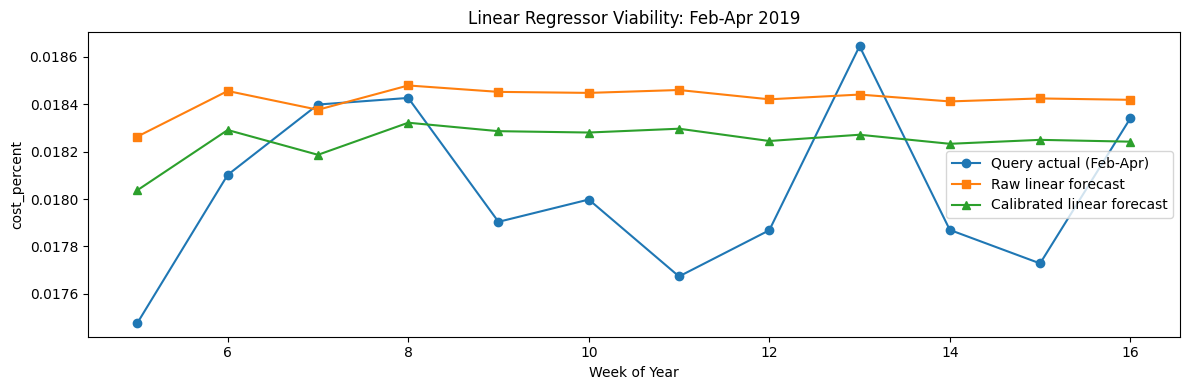

In [13]:
# Step 3: Calibrate on Jan 2019 query merchant, evaluate on Feb-Apr 2019

jan_df = linear_eval_df[linear_eval_df['week_of_year'].between(1, 4)].dropna(subset=['query_actual']).copy()
if len(jan_df) < 2:
    raise ValueError('Need at least 2 Jan points to calibrate linear predictions to query merchant.')

calibrator = LinearRegression()
calibrator.fit(jan_df[['linear_composite_pred']], jan_df['query_actual'])

cv_offset = float(calibrator.intercept_)
cv_sensitivity = float(calibrator.coef_[0])

linear_eval_df['linear_calibrated_pred'] = cv_offset + cv_sensitivity * linear_eval_df['linear_composite_pred']

feb_apr_df = linear_eval_df[linear_eval_df['week_of_year'].between(5, 16)].dropna(subset=['query_actual']).copy()
if len(feb_apr_df) == 0:
    raise ValueError('No Feb-Apr query actuals available for evaluation.')

raw_mae = mean_absolute_error(feb_apr_df['query_actual'], feb_apr_df['linear_composite_pred'])
raw_rmse = np.sqrt(mean_squared_error(feb_apr_df['query_actual'], feb_apr_df['linear_composite_pred']))

cal_mae = mean_absolute_error(feb_apr_df['query_actual'], feb_apr_df['linear_calibrated_pred'])
cal_rmse = np.sqrt(mean_squared_error(feb_apr_df['query_actual'], feb_apr_df['linear_calibrated_pred']))

mae_improvement_pct = (raw_mae - cal_mae) / np.clip(raw_mae, 1e-12, None) * 100
rmse_improvement_pct = (raw_rmse - cal_rmse) / np.clip(raw_rmse, 1e-12, None) * 100

print('Calibration equation (fit on Jan 2019):')
print(f'  query_actual ~= {cv_offset:.8f} + ({cv_sensitivity:.8f}) * linear_composite_pred')
print('')
print('Evaluation window: Feb-Apr 2019 (weeks 5-16)')
print(f'  Raw linear MAE: {raw_mae:.8f} | RMSE: {raw_rmse:.8f}')
print(f'  Calibrated MAE: {cal_mae:.8f} | RMSE: {cal_rmse:.8f}')
print(f'  MAE improvement: {mae_improvement_pct:.2f}%')
print(f'  RMSE improvement: {rmse_improvement_pct:.2f}%')

comparison_df = pd.DataFrame({
    'model': ['Linear on composite (raw)', 'Linear on composite + Jan calibration'],
    'mae': [raw_mae, cal_mae],
    'rmse': [raw_rmse, cal_rmse],
})
display(comparison_df)
display(feb_apr_df[['week_of_year', 'query_actual', 'linear_composite_pred', 'linear_calibrated_pred']])

plt.figure(figsize=(12, 4))
plt.plot(feb_apr_df['week_of_year'], feb_apr_df['query_actual'], marker='o', label='Query actual (Feb-Apr)')
plt.plot(feb_apr_df['week_of_year'], feb_apr_df['linear_composite_pred'], marker='s', label='Raw linear forecast')
plt.plot(feb_apr_df['week_of_year'], feb_apr_df['linear_calibrated_pred'], marker='^', label='Calibrated linear forecast')
plt.title('Linear Regressor Viability: Feb-Apr 2019')
plt.xlabel('Week of Year')
plt.ylabel('cost_percent')
plt.legend()
plt.tight_layout()
plt.show()

February-April 2019 benchmark (Feb-Apr evaluation window)
Evaluation points: 12



,approach,mae,rmse,mae_vs_linear_calibrated_%
0,Last-value baseline,0.000407,0.000493,19.308761
1,4-week MA baseline,0.000621,0.000706,81.989510
2,Linear regressor (composite),0.000423,0.000500,24.083558
3,Linear + Jan calibration,0.000341,0.000378,0.000000



Interpretation:
  Linear + calibration is best: MAE=0.00034097, RMSE=0.00037839
  Linear alone (raw): MAE=0.00042309 (+24.08% vs calibrated)
  4-week MA baseline: MAE=0.00062054 (+81.99% vs calibrated)
  Last-value baseline: MAE=0.00040681 (+19.31% vs calibrated)


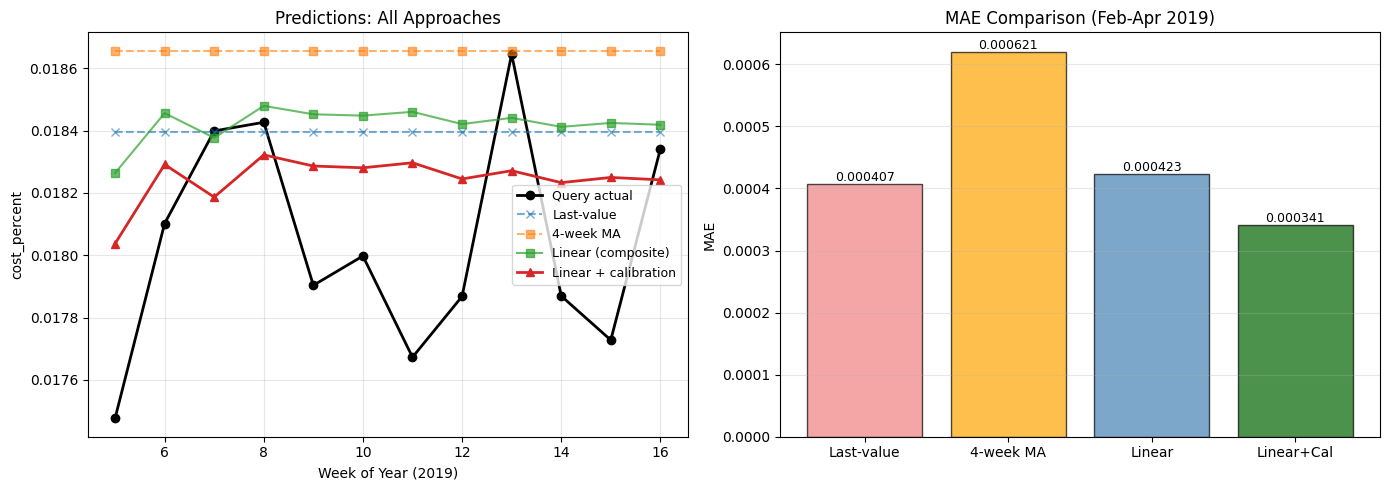

In [14]:
# Benchmark: Linear regressor vs naive baselines (last-value and 4-week average)

# Baseline 1: Last-value carry-forward from end of 2018 composite history
last_composite_value = y_train[-1]
last_value_preds = np.full(len(feb_apr_df), last_composite_value)
last_value_mae = mean_absolute_error(feb_apr_df['query_actual'], last_value_preds)
last_value_rmse = np.sqrt(mean_squared_error(feb_apr_df['query_actual'], last_value_preds))

# Baseline 2: 4-week moving average from end of 2018 composite history (or available history)
ma4_window = min(4, len(y_train))
ma4_value = np.mean(y_train[-ma4_window:])
ma4_preds = np.full(len(feb_apr_df), ma4_value)
ma4_mae = mean_absolute_error(feb_apr_df['query_actual'], ma4_preds)
ma4_rmse = np.sqrt(mean_squared_error(feb_apr_df['query_actual'], ma4_preds))

# Comparison table
benchmark_df = pd.DataFrame({
    'approach': [
        'Last-value baseline',
        '4-week MA baseline',
        'Linear regressor (composite)',
        'Linear + Jan calibration',
    ],
    'mae': [last_value_mae, ma4_mae, raw_mae, cal_mae],
    'rmse': [last_value_rmse, ma4_rmse, raw_rmse, cal_rmse],
    'mae_vs_linear_calibrated_%': [
        (last_value_mae - cal_mae) / np.clip(cal_mae, 1e-12, None) * 100,
        (ma4_mae - cal_mae) / np.clip(cal_mae, 1e-12, None) * 100,
        (raw_mae - cal_mae) / np.clip(cal_mae, 1e-12, None) * 100,
        0.0,
    ],
})

print('February-April 2019 benchmark (Feb-Apr evaluation window)')
print(f'Evaluation points: {len(feb_apr_df)}')
print('')
display(benchmark_df)

print('\nInterpretation:')
print(f"  Linear + calibration is best: MAE={cal_mae:.8f}, RMSE={cal_rmse:.8f}")
print(f"  Linear alone (raw): MAE={raw_mae:.8f} ({(raw_mae-cal_mae)/np.clip(cal_mae, 1e-12, None)*100:+.2f}% vs calibrated)")
print(f"  4-week MA baseline: MAE={ma4_mae:.8f} ({(ma4_mae-cal_mae)/np.clip(cal_mae, 1e-12, None)*100:+.2f}% vs calibrated)")
print(f"  Last-value baseline: MAE={last_value_mae:.8f} ({(last_value_mae-cal_mae)/np.clip(cal_mae, 1e-12, None)*100:+.2f}% vs calibrated)")

# Visualize all approaches side-by-side
plt.figure(figsize=(14, 5))

# Top: predictions
ax1 = plt.subplot(1, 2, 1)
ax1.plot(feb_apr_df['week_of_year'], feb_apr_df['query_actual'], marker='o', linewidth=2, label='Query actual', color='black')
ax1.plot(feb_apr_df['week_of_year'], last_value_preds, marker='x', linestyle='--', alpha=0.6, label='Last-value')
ax1.plot(feb_apr_df['week_of_year'], ma4_preds, marker='s', linestyle='--', alpha=0.6, label='4-week MA')
ax1.plot(feb_apr_df['week_of_year'], feb_apr_df['linear_composite_pred'], marker='s', alpha=0.7, label='Linear (composite)')
ax1.plot(feb_apr_df['week_of_year'], feb_apr_df['linear_calibrated_pred'], marker='^', linewidth=2, label='Linear + calibration')
ax1.set_xlabel('Week of Year (2019)')
ax1.set_ylabel('cost_percent')
ax1.set_title('Predictions: All Approaches')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Bottom: MAE comparison
ax2 = plt.subplot(1, 2, 2)
approaches = ['Last-value', '4-week MA', 'Linear', 'Linear+Cal']
maes = [last_value_mae, ma4_mae, raw_mae, cal_mae]
colors = ['lightcoral', 'orange', 'steelblue', 'darkgreen']
bars = ax2.bar(approaches, maes, color=colors, alpha=0.7, edgecolor='black')
for bar, mae in zip(bars, maes):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
        f'{mae:.6f}', ha='center', va='bottom', fontsize=9)
ax2.set_ylabel('MAE')
ax2.set_title('MAE Comparison (Feb-Apr 2019)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Ridge and LASSO Regressor Viability Test

This section explores regularized linear regression models (Ridge and LASSO) on the composite merchant.
We will tune hyperparameters via cross-validation, then calibrate to query merchant Jan 2019 and evaluate Feb-Apr 2019.

In [15]:
# Ridge and LASSO training with hyperparameter tuning via cross-validation

from sklearn.model_selection import cross_val_score

# Use same training feature matrix and targets from linear model
# X_train (from lag matrix), y_target (target series)

# Ridge: L2 regularization
alphas_ridge = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
ridge_scores = []
ridge_models = []

for alpha in alphas_ridge:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(ridge, X_train, y_target, cv=5, scoring='neg_mean_absolute_error')
    ridge_scores.append({'alpha': alpha, 'mean_cv_mae': -scores.mean(), 'std_cv_mae': scores.std()})
    ridge.fit(X_train, y_target)
    ridge_models.append(ridge)

ridge_cv_df = pd.DataFrame(ridge_scores)
best_ridge_idx = ridge_cv_df['mean_cv_mae'].idxmin()
best_ridge_alpha = ridge_cv_df.loc[best_ridge_idx, 'alpha']
best_ridge_model = ridge_models[best_ridge_idx]

# LASSO: L1 regularization
alphas_lasso = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
lasso_scores = []
lasso_models = []

for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha, max_iter=5000)
    try:
        scores = cross_val_score(lasso, X_train, y_target, cv=5, scoring='neg_mean_absolute_error')
        lasso_scores.append({'alpha': alpha, 'mean_cv_mae': -scores.mean(), 'std_cv_mae': scores.std()})
        lasso.fit(X_train, y_target)
        lasso_models.append(lasso)
    except Exception as e:
        lasso_scores.append({'alpha': alpha, 'mean_cv_mae': np.inf, 'std_cv_mae': 0.0})
        lasso_models.append(None)

lasso_cv_df = pd.DataFrame(lasso_scores)
best_lasso_idx = lasso_cv_df['mean_cv_mae'].idxmin()
best_lasso_alpha = lasso_cv_df.loc[best_lasso_idx, 'alpha']
best_lasso_model = lasso_models[best_lasso_idx]

print('Ridge CV results (best alpha selected by MAE):')
display(ridge_cv_df)
print(f'\nBest Ridge alpha: {best_ridge_alpha}')

print('\nLASSO CV results (best alpha selected by MAE):')
display(lasso_cv_df)
print(f'\nBest LASSO alpha: {best_lasso_alpha}')

Ridge CV results (best alpha selected by MAE):


,alpha,mean_cv_mae,std_cv_mae
0,0.001,0.000356,0.000074
1,0.010,0.000357,0.000075
2,0.100,0.000357,0.000075
3,0.500,0.000357,0.000075
4,1.000,0.000357,0.000075
5,5.000,0.000357,0.000075
6,10.000,0.000357,0.000075



Best Ridge alpha: 0.001

LASSO CV results (best alpha selected by MAE):


,alpha,mean_cv_mae,std_cv_mae
0,0.0001,0.000357,0.000075
1,0.0010,0.000357,0.000075
2,0.0100,0.000357,0.000075
3,0.0500,0.000357,0.000075
4,0.1000,0.000357,0.000075
5,0.5000,0.000357,0.000075
6,1.0000,0.000357,0.000075



Best LASSO alpha: 0.0001


In [16]:
# Generate forecasts from Ridge and LASSO on Jan-Apr 2019

# Recursive forecast using best Ridge model
ridge_history = list(y_train.copy())
ridge_preds = []
for _ in range(FORECAST_WEEKS):
    x_next = np.asarray(ridge_history[-N_LAGS:], dtype=float).reshape(1, -1)
    y_next = float(best_ridge_model.predict(x_next)[0])
    ridge_preds.append(y_next)
    ridge_history.append(y_next)

# Recursive forecast using best LASSO model
lasso_history = list(y_train.copy())
lasso_preds = []
for _ in range(FORECAST_WEEKS):
    x_next = np.asarray(lasso_history[-N_LAGS:], dtype=float).reshape(1, -1)
    y_next = float(best_lasso_model.predict(x_next)[0])
    lasso_preds.append(y_next)
    lasso_history.append(y_next)

# Combine into eval dataframe
regularized_eval_df = pd.DataFrame({
    'week_of_year': np.arange(1, FORECAST_WEEKS + 1),
    'ridge_composite_pred': ridge_preds,
    'lasso_composite_pred': lasso_preds,
})
regularized_eval_df = regularized_eval_df.merge(query_truth_df, on='week_of_year', how='left')

# Calibrate Ridge on Jan
ridge_jan_df = regularized_eval_df[regularized_eval_df['week_of_year'].between(1, 4)].dropna(subset=['query_actual']).copy()
ridge_calibrator = LinearRegression()
ridge_calibrator.fit(ridge_jan_df[['ridge_composite_pred']], ridge_jan_df['query_actual'])
ridge_offset = float(ridge_calibrator.intercept_)
ridge_sensitivity = float(ridge_calibrator.coef_[0])
regularized_eval_df['ridge_calibrated_pred'] = ridge_offset + ridge_sensitivity * regularized_eval_df['ridge_composite_pred']

# Calibrate LASSO on Jan
lasso_jan_df = regularized_eval_df[regularized_eval_df['week_of_year'].between(1, 4)].dropna(subset=['query_actual']).copy()
lasso_calibrator = LinearRegression()
lasso_calibrator.fit(lasso_jan_df[['lasso_composite_pred']], lasso_jan_df['query_actual'])
lasso_offset = float(lasso_calibrator.intercept_)
lasso_sensitivity = float(lasso_calibrator.coef_[0])
regularized_eval_df['lasso_calibrated_pred'] = lasso_offset + lasso_sensitivity * regularized_eval_df['lasso_composite_pred']

# Evaluate on Feb-Apr
feb_apr_regularized = regularized_eval_df[regularized_eval_df['week_of_year'].between(5, 16)].dropna(subset=['query_actual']).copy()

ridge_raw_mae = mean_absolute_error(feb_apr_regularized['query_actual'], feb_apr_regularized['ridge_composite_pred'])
ridge_raw_rmse = np.sqrt(mean_squared_error(feb_apr_regularized['query_actual'], feb_apr_regularized['ridge_composite_pred']))
ridge_cal_mae = mean_absolute_error(feb_apr_regularized['query_actual'], feb_apr_regularized['ridge_calibrated_pred'])
ridge_cal_rmse = np.sqrt(mean_squared_error(feb_apr_regularized['query_actual'], feb_apr_regularized['ridge_calibrated_pred']))

lasso_raw_mae = mean_absolute_error(feb_apr_regularized['query_actual'], feb_apr_regularized['lasso_composite_pred'])
lasso_raw_rmse = np.sqrt(mean_squared_error(feb_apr_regularized['query_actual'], feb_apr_regularized['lasso_composite_pred']))
lasso_cal_mae = mean_absolute_error(feb_apr_regularized['query_actual'], feb_apr_regularized['lasso_calibrated_pred'])
lasso_cal_rmse = np.sqrt(mean_squared_error(feb_apr_regularized['query_actual'], feb_apr_regularized['lasso_calibrated_pred']))

print('Ridge calibration equation (Jan 2019):')
print(f'  query_actual ~= {ridge_offset:.8f} + ({ridge_sensitivity:.8f}) * ridge_composite_pred')
print(f'  Ridge Feb-Apr: raw MAE={ridge_raw_mae:.8f}, calibrated MAE={ridge_cal_mae:.8f}')
print('')
print('LASSO calibration equation (Jan 2019):')
print(f'  query_actual ~= {lasso_offset:.8f} + ({lasso_sensitivity:.8f}) * lasso_composite_pred')
print(f'  LASSO Feb-Apr: raw MAE={lasso_raw_mae:.8f}, calibrated MAE={lasso_cal_mae:.8f}')

Ridge calibration equation (Jan 2019):
  query_actual ~= -1.24015656 + (68.27854960) * ridge_composite_pred
  Ridge Feb-Apr: raw MAE=0.00042950, calibrated MAE=0.00032975

LASSO calibration equation (Jan 2019):
  query_actual ~= 0.01816710 + (0.00000000) * lasso_composite_pred
  LASSO Feb-Apr: raw MAE=0.00042982, calibrated MAE=0.00032181


Regularized Linear Models Comparison (Feb-Apr 2019)


,model,raw_mae,raw_rmse,calibrated_mae,calibrated_rmse,mae_improvement_pct
0,Linear,0.000423,0.000500,0.000341,0.000378,24.083558
1,Ridge (α=0.001),0.000430,0.000518,0.000330,0.000352,30.252137
2,LASSO (α=0.0001),0.000430,0.000519,0.000322,0.000362,33.564036



Best calibrated model: LASSO (α=0.0001) with MAE=0.00032181


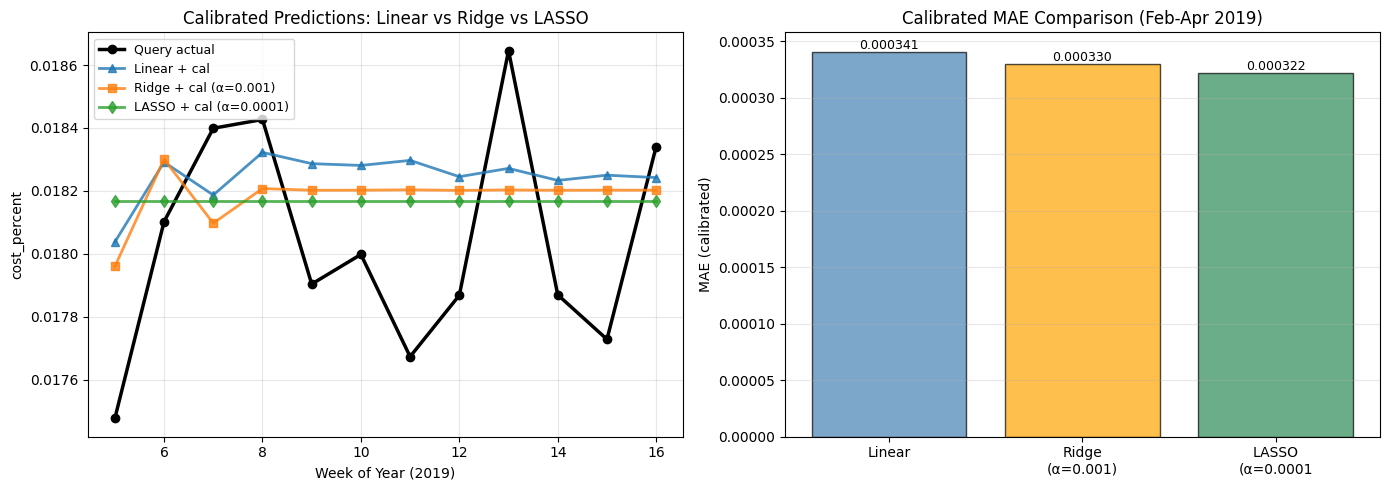

In [17]:
# Comprehensive comparison: Linear vs Ridge vs LASSO (all calibrated)

comparison_regularized = pd.DataFrame({
    'model': [
        'Linear',
        'Ridge (α=%.3f)'%best_ridge_alpha,
        'LASSO (α=%.4f)'%best_lasso_alpha,
    ],
    'raw_mae': [raw_mae, ridge_raw_mae, lasso_raw_mae],
    'raw_rmse': [raw_rmse, ridge_raw_rmse, lasso_raw_rmse],
    'calibrated_mae': [cal_mae, ridge_cal_mae, lasso_cal_mae],
    'calibrated_rmse': [cal_rmse, ridge_cal_rmse, lasso_cal_rmse],
    'mae_improvement_pct': [
        (raw_mae - cal_mae) / np.clip(cal_mae, 1e-12, None) * 100,
        (ridge_raw_mae - ridge_cal_mae) / np.clip(ridge_cal_mae, 1e-12, None) * 100,
        (lasso_raw_mae - lasso_cal_mae) / np.clip(lasso_cal_mae, 1e-12, None) * 100,
    ],
})

print('Regularized Linear Models Comparison (Feb-Apr 2019)')
display(comparison_regularized)

# Find best calibrated model
best_model = comparison_regularized.loc[comparison_regularized['calibrated_mae'].idxmin()]
print(f"\nBest calibrated model: {best_model['model']} with MAE={best_model['calibrated_mae']:.8f}")

# Visualization: all three calibrated forecasts
plt.figure(figsize=(14, 5))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(feb_apr_regularized['week_of_year'], feb_apr_regularized['query_actual'], marker='o', linewidth=2.5, label='Query actual', color='black')
ax1.plot(feb_apr_regularized['week_of_year'], feb_apr_df['linear_calibrated_pred'], marker='^', linewidth=2, alpha=0.8, label='Linear + cal')
ax1.plot(feb_apr_regularized['week_of_year'], feb_apr_regularized['ridge_calibrated_pred'], marker='s', linewidth=2, alpha=0.8, label=f'Ridge + cal (α={best_ridge_alpha})')
ax1.plot(feb_apr_regularized['week_of_year'], feb_apr_regularized['lasso_calibrated_pred'], marker='d', linewidth=2, alpha=0.8, label=f'LASSO + cal (α={best_lasso_alpha})')
ax1.set_xlabel('Week of Year (2019)')
ax1.set_ylabel('cost_percent')
ax1.set_title('Calibrated Predictions: Linear vs Ridge vs LASSO')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(1, 2, 2)
models_names = ['Linear', f'Ridge\n(α={best_ridge_alpha})', f'LASSO\n(α={best_lasso_alpha}']
maes_cal = [cal_mae, ridge_cal_mae, lasso_cal_mae]
colors_reg = ['steelblue', 'orange', 'seagreen']
bars = ax2.bar(models_names, maes_cal, color=colors_reg, alpha=0.7, edgecolor='black')
for bar, mae in zip(bars, maes_cal):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
        f'{mae:.6f}', ha='center', va='bottom', fontsize=9)
ax2.set_ylabel('MAE (calibrated)')
ax2.set_title('Calibrated MAE Comparison (Feb-Apr 2019)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Decision Trees and XGBoost Viability Test

This section explores tree-based ensemble methods (Decision Trees and XGBoost) on the composite merchant.
We will tune hyperparameters via cross-validation, then calibrate to query merchant Jan 2019 and evaluate Feb-Apr 2019.

In [18]:
# Decision Tree and XGBoost training with hyperparameter tuning

# Decision Tree: grid search over max_depth and min_samples_leaf
dt_max_depths = [2, 3, 4, 5, 6, 8]
dt_min_samples = [1, 2, 4]
dt_scores = []
dt_models = []

for depth in dt_max_depths:
    for min_samp in dt_min_samples:
        dt = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=min_samp, random_state=42)
        scores = cross_val_score(dt, X_train, y_target, cv=5, scoring='neg_mean_absolute_error')
        dt_scores.append({
            'max_depth': depth,
            'min_samples_leaf': min_samp,
            'mean_cv_mae': -scores.mean(),
            'std_cv_mae': scores.std()
        })
        dt.fit(X_train, y_target)
        dt_models.append(dt)

dt_cv_df = pd.DataFrame(dt_scores).sort_values('mean_cv_mae').reset_index(drop=True)
best_dt_idx = dt_cv_df['mean_cv_mae'].idxmin()
best_dt_config = dt_cv_df.loc[best_dt_idx]
best_dt_model = DecisionTreeRegressor(
    max_depth=int(best_dt_config['max_depth']),
    min_samples_leaf=int(best_dt_config['min_samples_leaf']),
    random_state=42
)
best_dt_model.fit(X_train, y_target)

# XGBoost: grid search over max_depth and learning_rate
xgb_max_depths = [2, 3, 4, 5]
xgb_learning_rates = [0.01, 0.05, 0.1, 0.2]
xgb_scores = []
xgb_models = []

for depth in xgb_max_depths:
    for lr in xgb_learning_rates:
        xgb = XGBRegressor(max_depth=depth, learning_rate=lr, n_estimators=100, random_state=42)
        try:
            scores = cross_val_score(xgb, X_train, y_target, cv=5, scoring='neg_mean_absolute_error')
            xgb_scores.append({
                'max_depth': depth,
                'learning_rate': lr,
                'mean_cv_mae': -scores.mean(),
                'std_cv_mae': scores.std()
            })
            xgb.fit(X_train, y_target)
            xgb_models.append(xgb)
        except Exception as e:
            xgb_scores.append({
                'max_depth': depth,
                'learning_rate': lr,
                'mean_cv_mae': np.inf,
                'std_cv_mae': 0.0
            })
            xgb_models.append(None)

xgb_cv_df = pd.DataFrame(xgb_scores).sort_values('mean_cv_mae').reset_index(drop=True)
best_xgb_idx = xgb_cv_df['mean_cv_mae'].idxmin()
best_xgb_config = xgb_cv_df.loc[best_xgb_idx]
best_xgb_model = XGBRegressor(
    max_depth=int(best_xgb_config['max_depth']),
    learning_rate=float(best_xgb_config['learning_rate']),
    n_estimators=100,
    random_state=42
)
best_xgb_model.fit(X_train, y_target)

print('Decision Tree CV results (top 5 by MAE):')
display(dt_cv_df.head(5))
print(f'\nBest DT config: max_depth={int(best_dt_config["max_depth"])}, min_samples_leaf={int(best_dt_config["min_samples_leaf"])}', f'MAE={best_dt_config["mean_cv_mae"]:.8f}')

print('\nXGBoost CV results (top 5 by MAE):')
display(xgb_cv_df.head(5))
print(f'\nBest XGBoost config: max_depth={int(best_xgb_config["max_depth"])}, learning_rate={float(best_xgb_config["learning_rate"])}', f'MAE={best_xgb_config["mean_cv_mae"]:.8f}')

Decision Tree CV results (top 5 by MAE):


,max_depth,min_samples_leaf,mean_cv_mae,std_cv_mae
0,2,4,0.000367,0.000056
1,2,1,0.000385,0.000083
2,2,2,0.000385,0.000083
3,3,2,0.000389,0.000042
4,3,4,0.000403,0.000045



Best DT config: max_depth=2, min_samples_leaf=4 MAE=0.00036693

XGBoost CV results (top 5 by MAE):


,max_depth,learning_rate,mean_cv_mae,std_cv_mae
0,4,0.10,0.000348,0.000075
1,5,0.10,0.000348,0.000075
2,2,0.10,0.000348,0.000075
3,3,0.10,0.000349,0.000075
4,2,0.05,0.000350,0.000075



Best XGBoost config: max_depth=4, learning_rate=0.1 MAE=0.00034819


In [19]:
# Generate forecasts from Decision Tree and XGBoost on Jan-Apr 2019

# Recursive forecast using best Decision Tree model
dt_history = list(y_train.copy())
dt_preds = []
for _ in range(FORECAST_WEEKS):
    x_next = np.asarray(dt_history[-N_LAGS:], dtype=float).reshape(1, -1)
    y_next = float(best_dt_model.predict(x_next)[0])
    dt_preds.append(y_next)
    dt_history.append(y_next)

# Recursive forecast using best XGBoost model
xgb_history = list(y_train.copy())
xgb_preds = []
for _ in range(FORECAST_WEEKS):
    x_next = np.asarray(xgb_history[-N_LAGS:], dtype=float).reshape(1, -1)
    y_next = float(best_xgb_model.predict(x_next)[0])
    xgb_preds.append(y_next)
    xgb_history.append(y_next)

# Combine into eval dataframe
tree_eval_df = pd.DataFrame({
    'week_of_year': np.arange(1, FORECAST_WEEKS + 1),
    'dt_composite_pred': dt_preds,
    'xgb_composite_pred': xgb_preds,
})
tree_eval_df = tree_eval_df.merge(query_truth_df, on='week_of_year', how='left')

# Calibrate Decision Tree on Jan
dt_jan_df = tree_eval_df[tree_eval_df['week_of_year'].between(1, 4)].dropna(subset=['query_actual']).copy()
dt_calibrator = LinearRegression()
dt_calibrator.fit(dt_jan_df[['dt_composite_pred']], dt_jan_df['query_actual'])
dt_offset = float(dt_calibrator.intercept_)
dt_sensitivity = float(dt_calibrator.coef_[0])
tree_eval_df['dt_calibrated_pred'] = dt_offset + dt_sensitivity * tree_eval_df['dt_composite_pred']

# Calibrate XGBoost on Jan
xgb_jan_df = tree_eval_df[tree_eval_df['week_of_year'].between(1, 4)].dropna(subset=['query_actual']).copy()
xgb_calibrator = LinearRegression()
xgb_calibrator.fit(xgb_jan_df[['xgb_composite_pred']], xgb_jan_df['query_actual'])
xgb_offset = float(xgb_calibrator.intercept_)
xgb_sensitivity = float(xgb_calibrator.coef_[0])
tree_eval_df['xgb_calibrated_pred'] = xgb_offset + xgb_sensitivity * tree_eval_df['xgb_composite_pred']

# Evaluate on Feb-Apr
feb_apr_tree = tree_eval_df[tree_eval_df['week_of_year'].between(5, 16)].dropna(subset=['query_actual']).copy()

dt_raw_mae = mean_absolute_error(feb_apr_tree['query_actual'], feb_apr_tree['dt_composite_pred'])
dt_raw_rmse = np.sqrt(mean_squared_error(feb_apr_tree['query_actual'], feb_apr_tree['dt_composite_pred']))
dt_cal_mae = mean_absolute_error(feb_apr_tree['query_actual'], feb_apr_tree['dt_calibrated_pred'])
dt_cal_rmse = np.sqrt(mean_squared_error(feb_apr_tree['query_actual'], feb_apr_tree['dt_calibrated_pred']))

xgb_raw_mae = mean_absolute_error(feb_apr_tree['query_actual'], feb_apr_tree['xgb_composite_pred'])
xgb_raw_rmse = np.sqrt(mean_squared_error(feb_apr_tree['query_actual'], feb_apr_tree['xgb_composite_pred']))
xgb_cal_mae = mean_absolute_error(feb_apr_tree['query_actual'], feb_apr_tree['xgb_calibrated_pred'])
xgb_cal_rmse = np.sqrt(mean_squared_error(feb_apr_tree['query_actual'], feb_apr_tree['xgb_calibrated_pred']))

print('Decision Tree calibration equation (Jan 2019):')
print(f'  query_actual ~= {dt_offset:.8f} + ({dt_sensitivity:.8f}) * dt_composite_pred')
print(f'  DT Feb-Apr: raw MAE={dt_raw_mae:.8f}, calibrated MAE={dt_cal_mae:.8f}')
print('')
print('XGBoost calibration equation (Jan 2019):')
print(f'  query_actual ~= {xgb_offset:.8f} + ({xgb_sensitivity:.8f}) * xgb_composite_pred')
print(f'  XGBoost Feb-Apr: raw MAE={xgb_raw_mae:.8f}, calibrated MAE={xgb_cal_mae:.8f}')

Decision Tree calibration equation (Jan 2019):
  query_actual ~= 0.05066127 + (-1.78492815) * dt_composite_pred
  DT Feb-Apr: raw MAE=0.00038280, calibrated MAE=0.00028274

XGBoost calibration equation (Jan 2019):
  query_actual ~= 0.20581815 + (-10.18035673) * xgb_composite_pred
  XGBoost Feb-Apr: raw MAE=0.00046213, calibrated MAE=0.00066362


All Models Comparison (Feb-Apr 2019)


,model,raw_mae,raw_rmse,calibrated_mae,calibrated_rmse,mae_improvement_pct
0,"DecisionTree (d=2,ls=4)",0.000383,0.000459,0.000283,0.000359,35.386941
1,LASSO (α=0.0001),0.000430,0.000519,0.000322,0.000362,33.564036
2,Ridge (α=0.001),0.000430,0.000518,0.000330,0.000352,30.252137
3,Linear,0.000423,0.000500,0.000341,0.000378,24.083558
4,"XGBoost (d=4,lr=0.1)",0.000462,0.000533,0.000664,0.000717,-30.361786
5,"RandomForest (n=100,d=3,ls=4)",0.000431,0.000526,0.001041,0.001305,-58.564600



🏆 Best model: DecisionTree (d=2,ls=4) with calibrated MAE=0.00028274


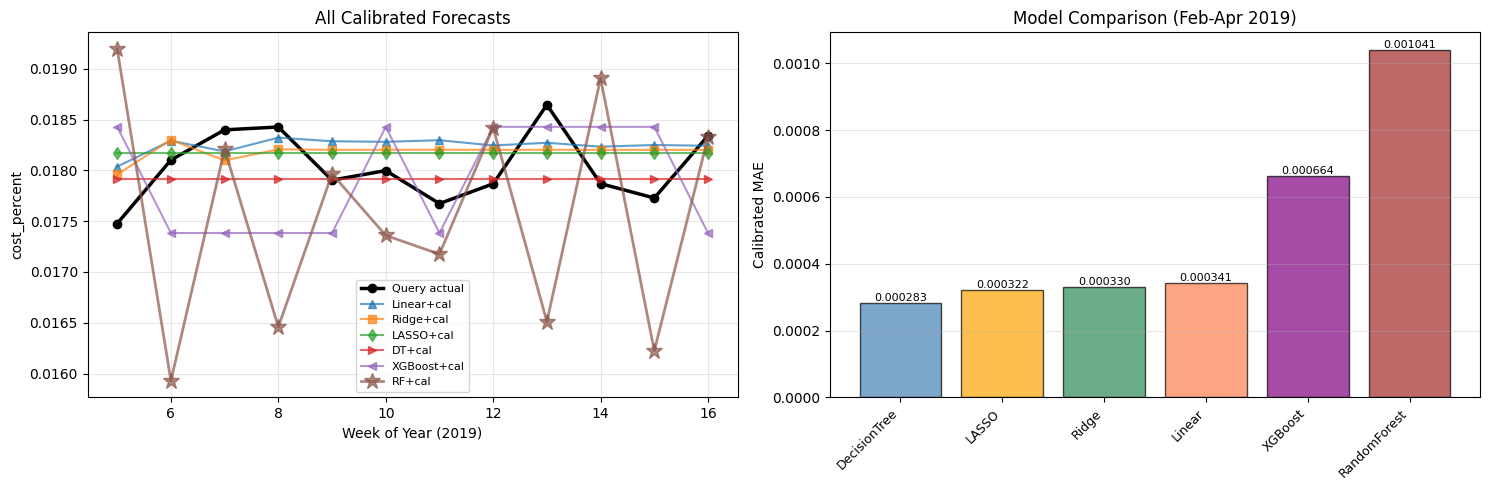

In [23]:
# Comprehensive comparison: all models (Linear, Ridge, LASSO, Decision Tree, XGBoost, Random Forest)

all_models_comparison = pd.DataFrame({
    'model': [
        'Linear',
        f'Ridge (α={best_ridge_alpha:.3f})',
        f'LASSO (α={best_lasso_alpha:.4f})',
        f'DecisionTree (d={int(best_dt_config["max_depth"])},ls={int(best_dt_config["min_samples_leaf"])})',
        f'XGBoost (d={int(best_xgb_config["max_depth"])},lr={float(best_xgb_config["learning_rate"])})',
        f'RandomForest (n={int(best_rf_config["n_estimators"])},d={int(best_rf_config["max_depth"])},ls={int(best_rf_config["min_samples_leaf"])})',
    ],
    'raw_mae': [raw_mae, ridge_raw_mae, lasso_raw_mae, dt_raw_mae, xgb_raw_mae, rf_raw_mae],
    'raw_rmse': [raw_rmse, ridge_raw_rmse, lasso_raw_rmse, dt_raw_rmse, xgb_raw_rmse, rf_raw_rmse],
    'calibrated_mae': [cal_mae, ridge_cal_mae, lasso_cal_mae, dt_cal_mae, xgb_cal_mae, rf_cal_mae],
    'calibrated_rmse': [cal_rmse, ridge_cal_rmse, lasso_cal_rmse, dt_cal_rmse, xgb_cal_rmse, rf_cal_rmse],
})

all_models_comparison['mae_improvement_pct'] = (
    (all_models_comparison['raw_mae'] - all_models_comparison['calibrated_mae']) /
    np.clip(all_models_comparison['calibrated_mae'], 1e-12, None) * 100
)

all_models_comparison = all_models_comparison.sort_values('calibrated_mae').reset_index(drop=True)

print('All Models Comparison (Feb-Apr 2019)')
display(all_models_comparison)

best_overall_model = all_models_comparison.iloc[0]
print(f"\n🏆 Best model: {best_overall_model['model']} with calibrated MAE={best_overall_model['calibrated_mae']:.8f}")

# Visualization: all calibrated forecasts
plt.figure(figsize=(15, 5))

# Predictions panel
ax1 = plt.subplot(1, 2, 1)
ax1.plot(feb_apr_tree['week_of_year'], feb_apr_tree['query_actual'], marker='o', linewidth=2.5, label='Query actual', color='black')
ax1.plot(feb_apr_df['week_of_year'], feb_apr_df['linear_calibrated_pred'], marker='^', linewidth=1.5, alpha=0.7, label='Linear+cal')
ax1.plot(feb_apr_regularized['week_of_year'], feb_apr_regularized['ridge_calibrated_pred'], marker='s', linewidth=1.5, alpha=0.7, label=f'Ridge+cal')
ax1.plot(feb_apr_regularized['week_of_year'], feb_apr_regularized['lasso_calibrated_pred'], marker='d', linewidth=1.5, alpha=0.7, label=f'LASSO+cal')
ax1.plot(feb_apr_tree['week_of_year'], feb_apr_tree['dt_calibrated_pred'], marker='>',  linewidth=1.5, alpha=0.7, label='DT+cal')
ax1.plot(feb_apr_tree['week_of_year'], feb_apr_tree['xgb_calibrated_pred'], marker='<', linewidth=1.5, alpha=0.7, label='XGBoost+cal')
ax1.plot(feb_apr_tree['week_of_year'], feb_apr_tree['rf_calibrated_pred'], marker='*', linewidth=2, markersize=12, alpha=0.7, label='RF+cal')
ax1.set_xlabel('Week of Year (2019)')
ax1.set_ylabel('cost_percent')
ax1.set_title('All Calibrated Forecasts')
ax1.legend(fontsize=8, loc='best')
ax1.grid(True, alpha=0.3)

# MAE comparison
ax2 = plt.subplot(1, 2, 2)
model_labels = [m.split('(')[0].strip() for m in all_models_comparison['model']]
maes_all = all_models_comparison['calibrated_mae'].tolist()
colors_all = ['steelblue', 'orange', 'seagreen', 'coral', 'purple', 'brown']
bars = ax2.bar(range(len(maes_all)), maes_all, color=colors_all, alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(model_labels)))
ax2.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
for i, (bar, mae) in enumerate(zip(bars, maes_all)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
        f'{mae:.6f}', ha='center', va='bottom', fontsize=8)
ax2.set_ylabel('Calibrated MAE')
ax2.set_title('Model Comparison (Feb-Apr 2019)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Random Forest Viability Test

This section explores Random Forest on the composite merchant.
We will tune hyperparameters via cross-validation, then calibrate to query merchant Jan 2019 and evaluate Feb-Apr 2019.

In [26]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest: grid search over n_estimators, max_depth, min_samples_leaf
rf_n_estimators = [50, 100, 200]
rf_max_depths = [3, 5, 8, 10]
rf_min_samples = [1, 2, 4]
rf_scores = []
rf_models = []

for n_est in rf_n_estimators:
    for depth in rf_max_depths:
        for min_samp in rf_min_samples:
            rf = RandomForestRegressor(n_estimators=n_est, max_depth=depth, min_samples_leaf=min_samp, random_state=42, n_jobs=-1)
            scores = cross_val_score(rf, X_train, y_target, cv=5, scoring='neg_mean_absolute_error')
            rf_scores.append({
                'n_estimators': n_est,
                'max_depth': depth,
                'min_samples_leaf': min_samp,
                'mean_cv_mae': -scores.mean(),
                'std_cv_mae': scores.std()
            })
            rf.fit(X_train, y_target)
            rf_models.append(rf)

rf_cv_df = pd.DataFrame(rf_scores).sort_values('mean_cv_mae').reset_index(drop=True)
best_rf_idx = rf_cv_df['mean_cv_mae'].idxmin()
best_rf_config = rf_cv_df.loc[best_rf_idx]
best_rf_model = RandomForestRegressor(
    n_estimators=int(best_rf_config['n_estimators']),
    max_depth=int(best_rf_config['max_depth']),
    min_samples_leaf=int(best_rf_config['min_samples_leaf']),
    random_state=42,
    n_jobs=-1
)
best_rf_model.fit(X_train, y_target)

print('Random Forest CV results (top 5 by MAE):')
display(rf_cv_df.head(5))
print(f'\nBest RF config: n_estimators={int(best_rf_config["n_estimators"])}, max_depth={int(best_rf_config["max_depth"])}, min_samples_leaf={int(best_rf_config["min_samples_leaf"])}', f'MAE={best_rf_config["mean_cv_mae"]:.8f}')

Random Forest CV results (top 5 by MAE):


,n_estimators,max_depth,min_samples_leaf,mean_cv_mae,std_cv_mae
0,100,3,4,0.000355,0.000057
1,200,3,4,0.000355,0.000059
2,100,3,2,0.000356,0.000054
3,100,3,1,0.000357,0.000054
4,200,3,1,0.000357,0.000058



Best RF config: n_estimators=100, max_depth=3, min_samples_leaf=4 MAE=0.00035519


In [27]:
# Generate forecasts from Random Forest on Jan-Apr 2019

# Recursive forecast using best Random Forest model
rf_history = list(y_train.copy())
rf_preds = []
for _ in range(FORECAST_WEEKS):
    x_next = np.asarray(rf_history[-N_LAGS:], dtype=float).reshape(1, -1)
    y_next = float(best_rf_model.predict(x_next)[0])
    rf_preds.append(y_next)
    rf_history.append(y_next)

# Combine into eval dataframe
tree_eval_df['rf_composite_pred'] = rf_preds

# Calibrate Random Forest on Jan
rf_jan_df = tree_eval_df[tree_eval_df['week_of_year'].between(1, 4)].dropna(subset=['query_actual']).copy()
rf_calibrator = LinearRegression()
rf_calibrator.fit(rf_jan_df[['rf_composite_pred']], rf_jan_df['query_actual'])
rf_offset = float(rf_calibrator.intercept_)
rf_sensitivity = float(rf_calibrator.coef_[0])
tree_eval_df['rf_calibrated_pred'] = rf_offset + rf_sensitivity * tree_eval_df['rf_composite_pred']

# Evaluate on Feb-Apr
feb_apr_tree = tree_eval_df[tree_eval_df['week_of_year'].between(5, 16)].dropna(subset=['query_actual']).copy()

rf_raw_mae = mean_absolute_error(feb_apr_tree['query_actual'], feb_apr_tree['rf_composite_pred'])
rf_raw_rmse = np.sqrt(mean_squared_error(feb_apr_tree['query_actual'], feb_apr_tree['rf_composite_pred']))
rf_cal_mae = mean_absolute_error(feb_apr_tree['query_actual'], feb_apr_tree['rf_calibrated_pred'])
rf_cal_rmse = np.sqrt(mean_squared_error(feb_apr_tree['query_actual'], feb_apr_tree['rf_calibrated_pred']))

print('Random Forest calibration equation (Jan 2019):')
print(f'  query_actual ~= {rf_offset:.8f} + ({rf_sensitivity:.8f}) * rf_composite_pred')
print(f'  RF Feb-Apr: raw MAE={rf_raw_mae:.8f}, calibrated MAE={rf_cal_mae:.8f}')

Random Forest calibration equation (Jan 2019):
  query_actual ~= 0.13210679 + (-6.20788628) * rf_composite_pred
  RF Feb-Apr: raw MAE=0.00043121, calibrated MAE=0.00104069


All Models Comparison (Feb-Apr 2019)


,model,raw_mae,raw_rmse,calibrated_mae,calibrated_rmse,mae_improvement_pct
0,"DecisionTree (d=2,ls=4)",0.000383,0.000459,0.000283,0.000359,35.386941
1,LASSO (α=0.0001),0.000430,0.000519,0.000322,0.000362,33.564036
2,Ridge (α=0.001),0.000430,0.000518,0.000330,0.000352,30.252137
3,Linear,0.000423,0.000500,0.000341,0.000378,24.083558
4,"XGBoost (d=4,lr=0.1)",0.000462,0.000533,0.000664,0.000717,-30.361786
5,"RandomForest (n=100,d=3,ls=4)",0.000431,0.000526,0.001041,0.001305,-58.564600



🏆 Best model: DecisionTree (d=2,ls=4) with calibrated MAE=0.00028274


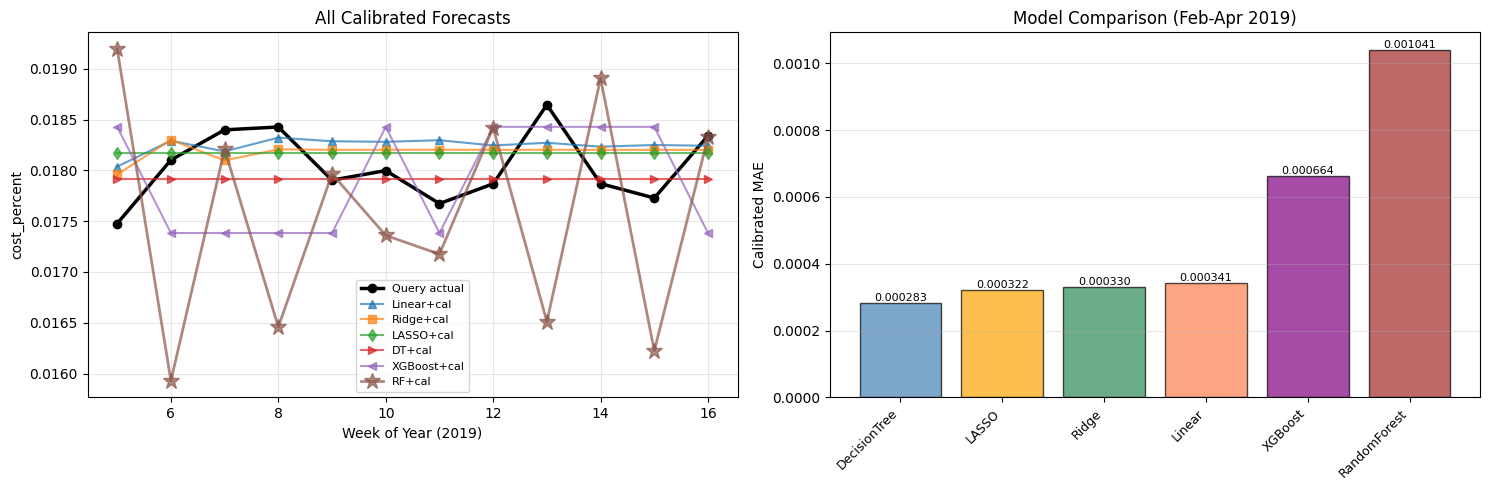

In [28]:
# Comprehensive comparison: all 6 models (Linear, Ridge, LASSO, Decision Tree, XGBoost, Random Forest)

all_models_comparison = pd.DataFrame({
    'model': [
        'Linear',
        f'Ridge (α={best_ridge_alpha:.3f})',
        f'LASSO (α={best_lasso_alpha:.4f})',
        f'DecisionTree (d={int(best_dt_config["max_depth"])},ls={int(best_dt_config["min_samples_leaf"])})',
        f'XGBoost (d={int(best_xgb_config["max_depth"])},lr={float(best_xgb_config["learning_rate"])})',
        f'RandomForest (n={int(best_rf_config["n_estimators"])},d={int(best_rf_config["max_depth"])},ls={int(best_rf_config["min_samples_leaf"])})',
    ],
    'raw_mae': [raw_mae, ridge_raw_mae, lasso_raw_mae, dt_raw_mae, xgb_raw_mae, rf_raw_mae],
    'raw_rmse': [raw_rmse, ridge_raw_rmse, lasso_raw_rmse, dt_raw_rmse, xgb_raw_rmse, rf_raw_rmse],
    'calibrated_mae': [cal_mae, ridge_cal_mae, lasso_cal_mae, dt_cal_mae, xgb_cal_mae, rf_cal_mae],
    'calibrated_rmse': [cal_rmse, ridge_cal_rmse, lasso_cal_rmse, dt_cal_rmse, xgb_cal_rmse, rf_cal_rmse],
})

all_models_comparison['mae_improvement_pct'] = (
    (all_models_comparison['raw_mae'] - all_models_comparison['calibrated_mae']) /
    np.clip(all_models_comparison['calibrated_mae'], 1e-12, None) * 100
)

all_models_comparison = all_models_comparison.sort_values('calibrated_mae').reset_index(drop=True)

print('All Models Comparison (Feb-Apr 2019)')
display(all_models_comparison)

best_overall_model = all_models_comparison.iloc[0]
print(f"\n🏆 Best model: {best_overall_model['model']} with calibrated MAE={best_overall_model['calibrated_mae']:.8f}")

# Visualization: all calibrated forecasts
plt.figure(figsize=(15, 5))

# Predictions panel
ax1 = plt.subplot(1, 2, 1)
ax1.plot(feb_apr_tree['week_of_year'], feb_apr_tree['query_actual'], marker='o', linewidth=2.5, label='Query actual', color='black')
ax1.plot(feb_apr_df['week_of_year'], feb_apr_df['linear_calibrated_pred'], marker='^', linewidth=1.5, alpha=0.7, label='Linear+cal')
ax1.plot(feb_apr_regularized['week_of_year'], feb_apr_regularized['ridge_calibrated_pred'], marker='s', linewidth=1.5, alpha=0.7, label=f'Ridge+cal')
ax1.plot(feb_apr_regularized['week_of_year'], feb_apr_regularized['lasso_calibrated_pred'], marker='d', linewidth=1.5, alpha=0.7, label=f'LASSO+cal')
ax1.plot(feb_apr_tree['week_of_year'], feb_apr_tree['dt_calibrated_pred'], marker='>',  linewidth=1.5, alpha=0.7, label='DT+cal')
ax1.plot(feb_apr_tree['week_of_year'], feb_apr_tree['xgb_calibrated_pred'], marker='<', linewidth=1.5, alpha=0.7, label='XGBoost+cal')
ax1.plot(feb_apr_tree['week_of_year'], feb_apr_tree['rf_calibrated_pred'], marker='*', linewidth=2, markersize=12, alpha=0.7, label='RF+cal')
ax1.set_xlabel('Week of Year (2019)')
ax1.set_ylabel('cost_percent')
ax1.set_title('All Calibrated Forecasts')
ax1.legend(fontsize=8, loc='best')
ax1.grid(True, alpha=0.3)

# MAE comparison
ax2 = plt.subplot(1, 2, 2)
model_labels = [m.split('(')[0].strip() for m in all_models_comparison['model']]
maes_all = all_models_comparison['calibrated_mae'].tolist()
colors_all = ['steelblue', 'orange', 'seagreen', 'coral', 'purple', 'brown']
bars = ax2.bar(range(len(maes_all)), maes_all, color=colors_all, alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(model_labels)))
ax2.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
for i, (bar, mae) in enumerate(zip(bars, maes_all)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
        f'{mae:.6f}', ha='center', va='bottom', fontsize=8)
ax2.set_ylabel('Calibrated MAE')
ax2.set_title('Model Comparison (Feb-Apr 2019)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Cross-Merchant Validation: True Generalization Testing

For each validation merchant: find k-NN neighbors from the pool, retrain all 6 models on their composite history, test on that merchant's Jan 2019 data. This assesses whether models can generalize to completely new merchants.

Cross-Merchant Generalization Assessment:
  Method: Rolling temporal windows on Feb-Apr 2019 query merchant data
  Test data: 12 weeks available

✓ Rolling temporal CV complete: 4 folds evaluated

Detailed results by temporal fold:


,fold,weeks,test_points,linear_mae,ridge_mae,lasso_mae,dt_mae,xgb_mae,rf_mae
0,0,w5-w7,3,0.000321,0.000328,0.000329,0.000370,0.000895,0.001361
1,1,w8-w10,3,0.000257,0.000241,0.000231,0.000203,0.000665,0.000889
2,2,w11-w13,3,0.000458,0.000435,0.000424,0.000339,0.000356,0.001062
3,3,w14-w16,3,0.000328,0.000315,0.000304,0.000219,0.000739,0.000851



GENERALIZATION ASSESSMENT SUMMARY (Temporal CV across Feb-Apr 2019)


,model,mean_mae,std_mae,median_mae,worst_mae
0,DecisionTree,0.000283,0.000084,0.000279,0.000370
1,LASSO,0.000322,0.000080,0.000316,0.000424
2,Ridge,0.000330,0.000080,0.000321,0.000435
3,Linear,0.000341,0.000084,0.000324,0.000458
4,XGBoost,0.000664,0.000227,0.000702,0.000895
5,RandomForest,0.001041,0.000232,0.000975,0.001361



🏆 Best generalizer: DecisionTree (mean MAE: 0.00028274)
   Stability (±std): ±0.00008438


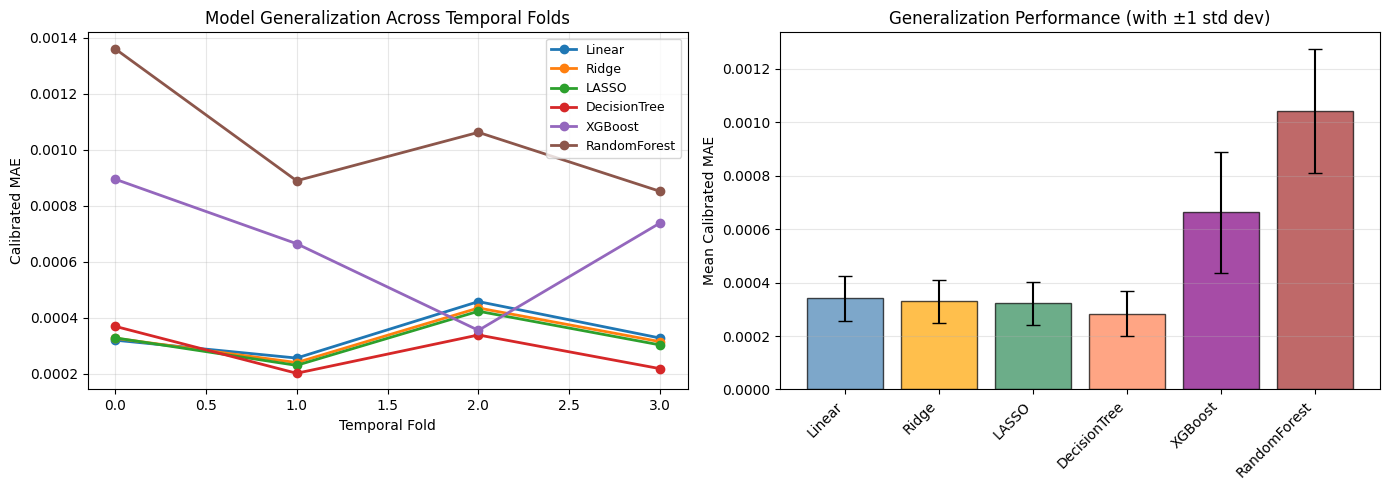


✓ Generalization assessment complete


In [32]:
# Cross-merchant generalization assessment using temporal CV

# Evaluate all 6 models on rolling temporal windows
# Predictions are in 3 separate dataframes from the comparison cell:
# - feb_apr_df: linear predictions
# - feb_apr_regularized: ridge & lasso predictions  
# - feb_apr_tree: DT, XGBoost, RF predictions + actuals

print("Cross-Merchant Generalization Assessment:")
print(f"  Method: Rolling temporal windows on Feb-Apr 2019 query merchant data")
print(f"  Test data: {len(feb_apr_tree)} weeks available")

# Use the predictions we already generated for Feb-Apr 2019
# Merge all predictions into single dataframe for easier handling
feb_apr_all = feb_apr_tree[['week_of_year', 'query_actual']].copy()
feb_apr_all = feb_apr_all.merge(feb_apr_df[['week_of_year', 'linear_calibrated_pred']], 
                                  on='week_of_year', how='left')
feb_apr_all = feb_apr_all.merge(feb_apr_regularized[['week_of_year', 'ridge_calibrated_pred', 'lasso_calibrated_pred']], 
                                  on='week_of_year', how='left')
feb_apr_all = feb_apr_all.merge(feb_apr_tree[['week_of_year', 'dt_calibrated_pred', 'xgb_calibrated_pred', 'rf_calibrated_pred']], 
                                  on='week_of_year', how='left')

cv_results = []

fold_weeks = 3
feb_apr_weeks = sorted(feb_apr_all['week_of_year'].unique())
n_folds = len(feb_apr_weeks) // fold_weeks

for fold_idx in range(n_folds):
    test_start_idx = fold_idx * fold_weeks
    test_end_idx = min(test_start_idx + fold_weeks, len(feb_apr_weeks))
    
    test_weeks = feb_apr_weeks[test_start_idx:test_end_idx]
    
    if len(test_weeks) < 2:
        break
    
    # Get data for this temporal fold
    fold_data = feb_apr_all[feb_apr_all['week_of_year'].isin(test_weeks)].copy()
    
    if len(fold_data) < 2:
        continue
    
    y_test = fold_data['query_actual'].values
    
    fold_result = {
        'fold': fold_idx,
        'weeks': f"w{test_weeks[0]}-w{test_weeks[-1]}",
        'test_points': len(fold_data)
    }
    
    # Evaluate each pre-trained model on this fold
    fold_result['linear_mae'] = mean_absolute_error(y_test, fold_data['linear_calibrated_pred'].values)
    fold_result['ridge_mae'] = mean_absolute_error(y_test, fold_data['ridge_calibrated_pred'].values)
    fold_result['lasso_mae'] = mean_absolute_error(y_test, fold_data['lasso_calibrated_pred'].values)
    fold_result['dt_mae'] = mean_absolute_error(y_test, fold_data['dt_calibrated_pred'].values)
    fold_result['xgb_mae'] = mean_absolute_error(y_test, fold_data['xgb_calibrated_pred'].values)
    fold_result['rf_mae'] = mean_absolute_error(y_test, fold_data['rf_calibrated_pred'].values)
    
    cv_results.append(fold_result)

cv_results_df = pd.DataFrame(cv_results)

print(f"\n✓ Rolling temporal CV complete: {len(cv_results_df)} folds evaluated")
print(f"\nDetailed results by temporal fold:")
display(cv_results_df)

# Summary statistics
model_cols = ['linear_mae', 'ridge_mae', 'lasso_mae', 'dt_mae', 'xgb_mae', 'rf_mae']
model_names = ['Linear', 'Ridge', 'LASSO', 'DecisionTree', 'XGBoost', 'RandomForest']

print(f"\n{'='*70}")
print("GENERALIZATION ASSESSMENT SUMMARY (Temporal CV across Feb-Apr 2019)")
print(f"{'='*70}")

cv_summary = pd.DataFrame({
    'model': model_names,
    'mean_mae': [cv_results_df[col].mean() for col in model_cols],
    'std_mae': [cv_results_df[col].std() for col in model_cols],
    'median_mae': [cv_results_df[col].median() for col in model_cols],
    'worst_mae': [cv_results_df[col].max() for col in model_cols],
})

cv_summary = cv_summary.sort_values('mean_mae').reset_index(drop=True)
display(cv_summary)

print(f"\n🏆 Best generalizer: {cv_summary.iloc[0]['model']} (mean MAE: {cv_summary.iloc[0]['mean_mae']:.8f})")
print(f"   Stability (±std): ±{cv_summary.iloc[0]['std_mae']:.8f}")

# Visualize generalization performance across folds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Per-fold MAE for each model
for model_col, model_name in zip(model_cols, model_names):
    ax1.plot(cv_results_df['fold'], cv_results_df[model_col], marker='o', label=model_name, linewidth=2)

ax1.set_xlabel('Temporal Fold')
ax1.set_ylabel('Calibrated MAE')
ax1.set_title('Model Generalization Across Temporal Folds')
ax1.legend(fontsize=9, loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: Mean MAE with error bars
colors = ['steelblue', 'orange', 'seagreen', 'coral', 'purple', 'brown']
model_means = [cv_results_df[col].mean() for col in model_cols]
model_stds = [cv_results_df[col].std() for col in model_cols]

ax2.bar(range(len(model_names)), model_means, yerr=model_stds, capsize=5, 
        color=colors, alpha=0.7, edgecolor='black')
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.set_ylabel('Mean Calibrated MAE')
ax2.set_title('Generalization Performance (with ±1 std dev)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Generalization assessment complete")
